In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
store = pd.read_csv(r"C:\Users\System -02\Downloads\csv file sales data.csv")

In [5]:
store.head(5)

,order_id,order_date,customer_name,product_name,product_category,quantity,Unnamed: 6,unit_price
0,100626,1/1/2021,Customer_1154,Laptop,Electronics,4,NaN,24813
1,100817,1/1/2021,Customer_565,Chair,Electronics,8,NaN,7775
2,102564,1/1/2021,Customer_1132,Monitor,Furniture,4,NaN,12633
3,102720,1/1/2021,Customer_401,Monitor,Furniture,2,NaN,47834
4,102958,1/1/2021,Customer_619,Table,Office Supplies,9,NaN,27869


In [6]:
store = store.dropna(subset=['order_date'])

In [7]:
store.columns

Index(['order_id', 'order_date', 'customer_name', 'product_name',
       'product_category', 'quantity', 'Unnamed: 6', 'unit_price'],
      dtype='str')

In [8]:
store = store.loc[:, ~store.columns.str.contains('Unnamed')]

In [9]:
store.columns

Index(['order_id', 'order_date', 'customer_name', 'product_name',
       'product_category', 'quantity', 'unit_price'],
      dtype='str')

In [10]:
store['order_date'] = pd.to_datetime(store['order_date'],format ='mixed')

In [11]:
store['month'] = store['order_date'].dt.month
store['year'] = store['order_date'].dt.year

In [12]:
store['revenue'] = store['quantity']*store['unit_price']
store[['quantity','unit_price','revenue']].head(5)

,quantity,unit_price,revenue
0,4,24813,99252
1,8,7775,62200
2,4,12633,50532
3,2,47834,95668
4,9,27869,250821


In [13]:
store['month'] = store['order_date']

In [14]:
store['revenue'].sum()

np.int64(622958580)

In [15]:
store.groupby('product_category')['revenue'].sum().sort_values(ascending = False)

product_category
Furniture          214114493
Office Supplies    204874768
Electronics        203969319
Name: revenue, dtype: int64

In [16]:
store.groupby('product_name')['revenue'].sum().sort_values(ascending =False)

product_name
Mobile     97252240
Pen        93412045
Table      92013788
Laptop     90566949
Chair      85819119
Monitor    85539775
Printer    78354664
Name: revenue, dtype: int64

In [17]:
store.groupby('customer_name')['revenue'].sum().sort_values(ascending =False).head(10)

customer_name
Customer_1136    2061356
Customer_439     1784003
Customer_1138    1764609
Customer_133     1740843
Customer_528     1677982
Customer_820     1585777
Customer_1154    1540944
Customer_307     1488609
Customer_434     1483511
Customer_387     1475599
Name: revenue, dtype: int64

In [18]:
store.groupby(store['order_date'].dt.to_period('M'))['revenue'].sum().head(5)

order_date
2021-01    16614766
2021-02    14144679
2021-03    18101691
2021-04    16795964
2021-05    17402616
Freq: M, Name: revenue, dtype: int64

In [19]:
store.groupby('year')['revenue'].sum()

year
2021    185369384
2022    190214280
2023    192088663
2024     55286253
Name: revenue, dtype: int64

In [20]:
store['month'] = store['order_date'].dt.month
store[['month']].head(3)

,month
0,1
1,1
2,1


In [21]:
monthly_revenue = store.groupby('month')['revenue'].sum()

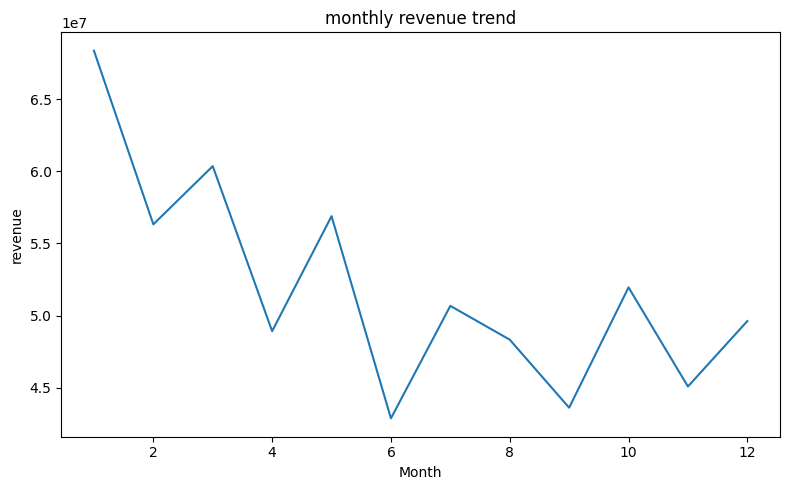

In [ ]:
monthly_revenue.plot(kind ='line',figsize = (8,5))
plt.title('monthly revenue trend')
plt.xlabel('Month')
plt.ylabel('revenue')
plt.tight_layout()
plt.show()

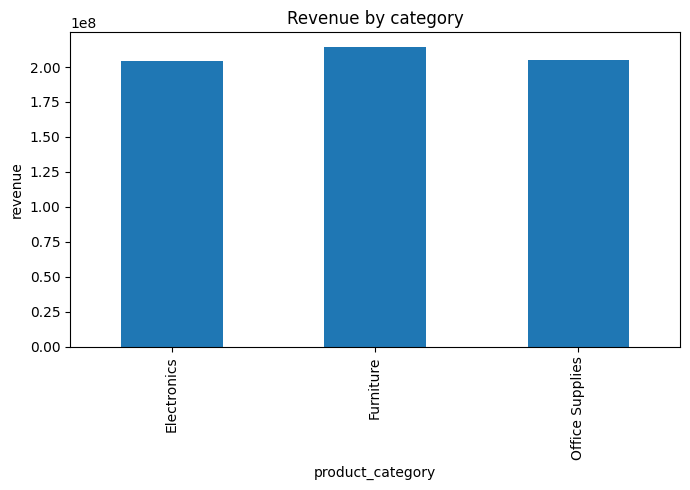

In [26]:
# revenue by category
category_revenue = store.groupby('product_category')['revenue'].sum()
category_revenue.plot(kind ='bar',figsize=(7,5))
plt.title('Revenue by category')
plt.xlabel('product_category')
plt.ylabel('revenue')
plt.tight_layout()
plt.show()

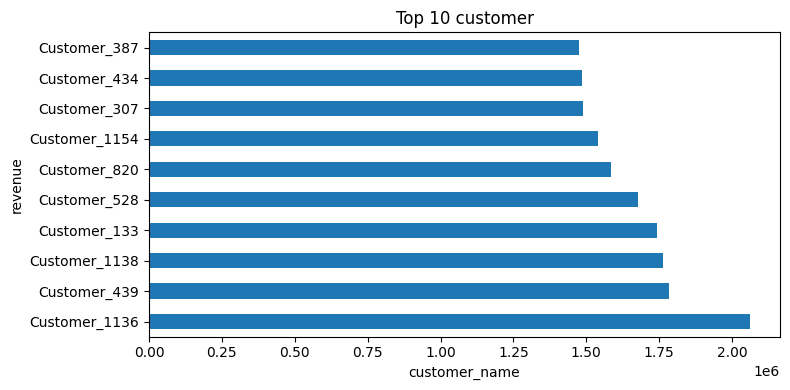

In [27]:
# top 10 customers
top_customers = store.groupby('customer_name')['revenue'].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind = 'barh',figsize = (8,4))
plt.title('Top 10 customer')
plt.xlabel('customer_name')
plt.ylabel('revenue')
plt.tight_layout()
plt.show()